# 01. Out-of-sample US inflation forecasting

**Question.** Do macro predictors and machine-learning models beat a simple
autoregression when forecasting US CPI inflation, once everything is evaluated *out of sample*?

**Design.**
- Target: average annualised CPI inflation over the next *h* months, h in {1, 3, 6, 12}.
- Expanding-window, *direct* forecasts. At each origin the models only see data up to that month.
- Hyper-parameters (ridge/lasso penalty, forest leaf size) are re-tuned every January with time-series cross-validation on the training sample only.
- Evaluation: 2001-01 onward. RMSE relative to an AR benchmark, Diebold-Mariano tests (Harvey-Leybourne-Newbold correction, HAC variance for overlapping horizons), and sub-samples.

**Limits.** FRED data are the *latest* vintage, not real-time vintages. Revised data flatter the predictors, so the results are an upper bound on what was achievable in real time.

In [1]:
import os, sys, warnings
os.environ["PYTHONWARNINGS"] = "ignore"      # also silences joblib worker processes
sys.path.insert(0, "src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from data_utils import fred
import statsmodels.api as sm
from IPython.display import display
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})

## 1. Data and features
Twelve standard monthly series from FRED, transformed to (approximately) stationary quantities.

CPI sample: 1959-01-31 -> 2026-08-31
(795, 19) features; 2 missing


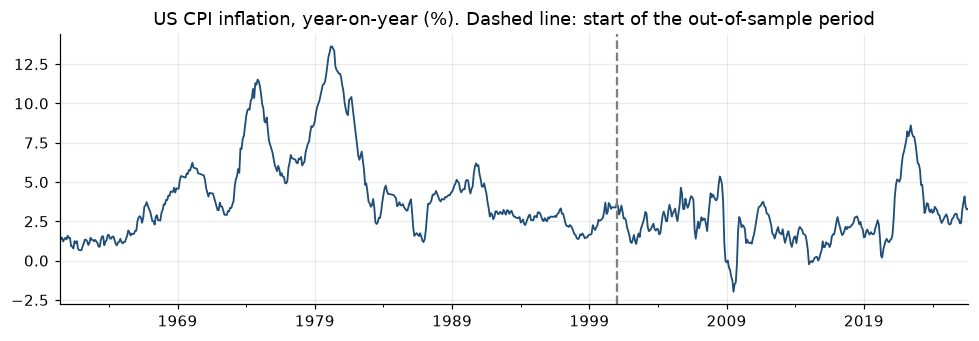

In [2]:
raw = pd.concat([fred(s) for s in ["CPIAUCSL","CPILFESL","UNRATE","INDPRO","FEDFUNDS","WTISPLC","M2SL","PAYEMS","HOUST","GS10","TB3MS","UMCSENT"]], axis=1)
raw.index = raw.index.to_period("M").to_timestamp("M")
raw = raw.loc["1959-01":]
last_cpi = raw["CPIAUCSL"].last_valid_index()
raw = raw.loc[:last_cpi]
print("CPI sample:", raw.index[0].date(), "->", last_cpi.date())

dl = lambda s, k=1: 1200 / k * np.log(s).diff(k)   # annualised log growth over k months
X = pd.DataFrame(index=raw.index)
X["infl"]      = dl(raw["CPIAUCSL"])
X["core"]      = dl(raw["CPILFESL"])
X["infl_3m"]   = dl(raw["CPIAUCSL"], 3)
X["infl_12m"]  = dl(raw["CPIAUCSL"], 12)
X["d_unrate"]  = raw["UNRATE"].diff(3)
X["unrate"]    = raw["UNRATE"]
X["ip"]        = dl(raw["INDPRO"], 3)
X["oil"]       = dl(raw["WTISPLC"], 3)
X["m2"]        = dl(raw["M2SL"], 12)
X["payrolls"]  = dl(raw["PAYEMS"], 3)
X["housing"]   = np.log(raw["HOUST"]).diff(3)
X["spread"]    = raw["GS10"] - raw["TB3MS"]
X["d_ffr"]     = raw["FEDFUNDS"].diff(3)
X["sentiment"] = raw["UMCSENT"].diff(3)
for k in (1, 2, 3, 4, 5):
    X[f"infl_l{k}"] = X["infl"].shift(k)
X = X.loc["1960-06":]
X = X.ffill(limit=2)      # a few predictors lag one month at the end of the sample
print(X.shape, "features;", int(X.isna().sum().sum()), "missing")

HORIZONS = [1, 3, 6, 12]
target = {h: 1200 / h * np.log(raw["CPIAUCSL"].shift(-h) / raw["CPIAUCSL"]) for h in HORIZONS}

fig, ax = plt.subplots(figsize=(9, 3.2))
X["infl_12m"].plot(ax=ax, lw=1.2, color="#1f4e79"); ax.axvline(pd.Timestamp("2001-01-31"), color="grey", ls="--")
ax.set_title("US CPI inflation, year-on-year (%). Dashed line: start of the out-of-sample period"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig("figures/01_inflation.png"); plt.show()

## 2. Models
- **RW12**: forecast = last 12-month average inflation (naive benchmark).
- **AR**: direct autoregression on monthly inflation, lag order chosen by BIC (1 to 6).
- **Phillips (ADL)**: AR(3) augmented with unemployment change, oil, term spread, rate change.
- **Ridge / Lasso**: all features, standardised, penalty tuned by time-series CV.
- **RandomForest**: 300 trees, min leaf size tuned by time-series CV.
- **Combo**: equal-weight average of AR, Phillips and Ridge.

In [3]:
PHILLIPS = ["infl","infl_l1","infl_l2","d_unrate","oil","spread","d_ffr"]
ALL = list(X.columns)

def ols_fc(Xtr, ytr, xnew):
    m = sm.OLS(ytr, sm.add_constant(Xtr, has_constant="add")).fit()
    return float(np.asarray(m.predict(sm.add_constant(xnew, has_constant="add")))[0])

def ar_forecast(tr_idx, t, y):
    best, bic = None, np.inf
    for p in range(1, 7):
        cols = ["infl"] + [f"infl_l{k}" for k in range(1, p)]
        d = pd.concat([X.loc[tr_idx, cols], y.loc[tr_idx]], axis=1).dropna()
        m = sm.OLS(d.iloc[:, -1], sm.add_constant(d.iloc[:, :-1])).fit()
        if m.bic < bic:
            bic, best = m.bic, (cols, m)
    cols, m = best
    return float(np.asarray(m.predict(sm.add_constant(X.loc[[t], cols], has_constant="add")))[0])

def tune(kind, Xtr, ytr):
    cv = TimeSeriesSplit(n_splits=5)
    sc = StandardScaler().fit(Xtr)
    if kind == "ridge":
        return RidgeCV(alphas=np.logspace(-1, 4, 30), cv=cv).fit(sc.transform(Xtr), ytr).alpha_
    if kind == "lasso":
        return LassoCV(alphas=np.logspace(-3, 1, 25), cv=cv, max_iter=20000).fit(sc.transform(Xtr), ytr).alpha_
    best, score = 5, np.inf
    for leaf in (5, 15, 40):
        errs = []
        for a, b in cv.split(Xtr):
            rf = RandomForestRegressor(100, min_samples_leaf=leaf, max_features=0.4, random_state=0, n_jobs=-1).fit(Xtr.iloc[a], ytr.iloc[a])
            errs.append(np.mean((rf.predict(Xtr.iloc[b]) - ytr.iloc[b]) ** 2))
        if np.mean(errs) < score:
            score, best = np.mean(errs), leaf
    return best

def run(h, start="2001-01-31"):
    y = target[h]
    origins = [t for t in X.index if t >= pd.Timestamp(start) and not np.isnan(y.get(t, np.nan))]
    rows, params, rf = [], {}, None
    complete = X.notna().all(axis=1) & y.reindex(X.index).notna()
    for t in origins:
        # only targets fully realised by month t are used for training
        tr_idx = X.index[(X.index <= t - pd.offsets.MonthEnd(h)) & complete]
        Xtr, ytr = X.loc[tr_idx], y.loc[tr_idx]
        xnew = X.loc[[t]]
        if t.month == 1 or not params:
            params = {k: tune(k, Xtr[ALL], ytr) for k in ("ridge", "lasso", "rf")}
            rf = None
        sc = StandardScaler().fit(Xtr[ALL])
        f = {"RW12": float(X.loc[t, "infl_12m"]),
             "AR": ar_forecast(tr_idx, t, y),
             "Phillips": ols_fc(Xtr[PHILLIPS], ytr, xnew[PHILLIPS]),
             "Ridge": float(Ridge(params["ridge"]).fit(sc.transform(Xtr[ALL]), ytr).predict(sc.transform(xnew[ALL]))[0]),
             "Lasso": float(Lasso(params["lasso"], max_iter=20000).fit(sc.transform(Xtr[ALL]), ytr).predict(sc.transform(xnew[ALL]))[0])}
        if rf is None or t.month in (1, 7):
            rf = RandomForestRegressor(300, min_samples_leaf=params["rf"], max_features=0.4, random_state=0, n_jobs=-1).fit(Xtr[ALL], ytr)
        f["RandomForest"] = float(rf.predict(xnew[ALL])[0])
        f["Combo"] = np.mean([f["AR"], f["Phillips"], f["Ridge"]])
        f["actual"] = float(y.loc[t])
        rows.append(pd.Series(f, name=t))
    return pd.DataFrame(rows)

FC = {}
for h in HORIZONS:
    FC[h] = run(h)
    print("horizon", h, "done:", FC[h].shape[0], "forecasts")
pd.concat(FC, axis=1).to_csv("data/out_01_forecasts.csv")

horizon 1 done: 305 forecasts
horizon 3 done: 303 forecasts
horizon 6 done: 300 forecasts
horizon 12 done: 295 forecasts


## 3. Results
RMSE ratios below 1 mean the model beats the AR benchmark. The Diebold-Mariano test uses a HAC variance (h-1 lags) and the Harvey-Leybourne-Newbold correction; stars mark the significance of the *improvement* over AR (one-sided: * 10%, ** 5%, *** 1%).

In [4]:
def dm_test(e_bench, e_model, h):
    d = e_bench ** 2 - e_model ** 2       # positive = model better
    n = len(d); dbar = d.mean()
    gam = [np.mean((d - dbar)[k:] * (d - dbar)[:n - k]) for k in range(h)]
    var = (gam[0] + 2 * sum(gam[1:])) / n
    dm = dbar / np.sqrt(var) if var > 0 else np.nan
    hln = dm * np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return hln, 1 - stats.t.cdf(hln, n - 1)

MODELS = ["RW12","Phillips","Ridge","Lasso","RandomForest","Combo"]
def table(period=None):
    out = {}
    for h in HORIZONS:
        df = FC[h] if period is None else FC[h].loc[period[0]:period[1]]
        e = df[["AR"] + MODELS].sub(df["actual"], axis=0)
        ar_rmse = np.sqrt((e["AR"] ** 2).mean())
        r = {"AR RMSE (pp)": f"{ar_rmse:.2f}", "n": len(df)}
        for m in MODELS:
            ratio = np.sqrt((e[m] ** 2).mean()) / ar_rmse
            _, p = dm_test(e["AR"].values, e[m].values, h)
            r[m] = f"{ratio:.2f}" + ("***" if p < .01 else "**" if p < .05 else "*" if p < .10 else "")
        out[f"h={h}"] = r
    return pd.DataFrame(out).T

print("FULL SAMPLE (ratio to AR RMSE)")
t_full = table(); display(t_full)
print("PRE-COVID 2001-2019"); t_pre = table(("2001", "2019-12-31")); display(t_pre)
print("2020 ONWARD (pandemic and post-pandemic inflation)"); t_post = table(("2020", "2030")); display(t_post)
t_full.to_csv("data/out_01_table_full.csv"); t_pre.to_csv("data/out_01_table_pre.csv"); t_post.to_csv("data/out_01_table_post.csv")

FULL SAMPLE (ratio to AR RMSE)


,AR RMSE (pp),n,RW12,Phillips,Ridge,Lasso,RandomForest,Combo
h=1,3.40,305,1.08,1.01,0.99,0.99,1.00,0.98
h=3,2.93,303,1.01,1.04,1.04,1.03,0.93**,1.00
h=6,2.40,300,1.00,1.04,1.05,1.09,0.87*,0.99
h=12,2.07,295,1.01,1.08,1.05,1.14,0.85,0.99


PRE-COVID 2001-2019


,AR RMSE (pp),n,RW12,Phillips,Ridge,Lasso,RandomForest,Combo
h=1,3.44,228,1.07,1.01,0.98*,0.98*,1.00,0.98
h=3,3.02,228,0.98,1.01,0.98,0.98,0.91**,0.97*
h=6,2.52,228,0.93**,1.03,1.01,1.01,0.83**,0.98*
h=12,2.03,228,0.87**,1.08,0.97***,0.97,0.81*,0.98


2020 ONWARD (pandemic and post-pandemic inflation)


,AR RMSE (pp),n,RW12,Phillips,Ridge,Lasso,RandomForest,Combo
h=1,3.29,77,1.12,1.02,1.03,1.03,1.01,1.00
h=3,2.64,75,1.13,1.13,1.22,1.22,1.01,1.08
h=6,1.98,72,1.30,1.09,1.25,1.43,1.03,1.04
h=12,2.19,67,1.33,1.08,1.25,1.54,0.97,1.04


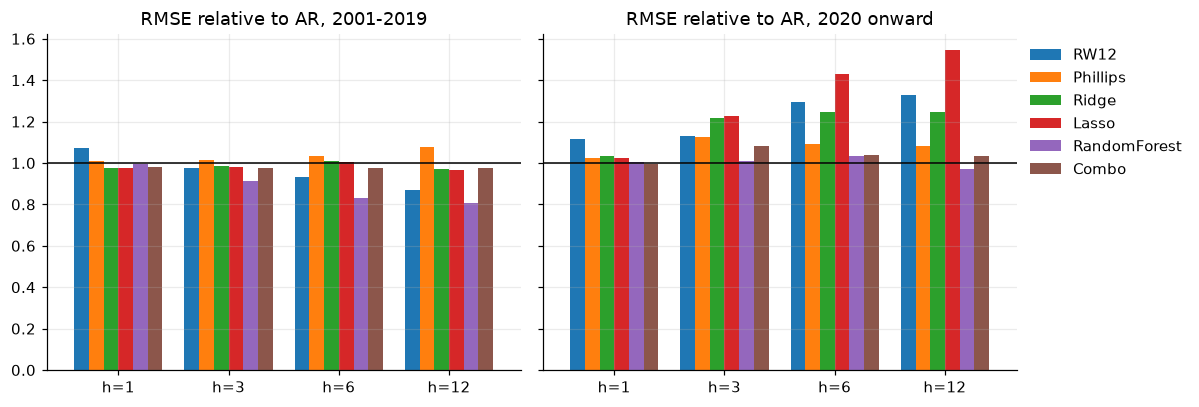

In [5]:
def rel(per):
    res = {}
    for m in MODELS:
        res[m] = []
        for h in HORIZONS:
            d = FC[h].loc[per[0]:per[1]]
            res[m].append(np.sqrt(((d[m] - d["actual"]) ** 2).mean()) / np.sqrt(((d["AR"] - d["actual"]) ** 2).mean()))
    return pd.DataFrame(res, index=[f"h={h}" for h in HORIZONS])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (name, per) in zip(axes, [("2001-2019", ("2001", "2019-12-31")), ("2020 onward", ("2020", "2030"))]):
    rel(per).plot.bar(ax=ax, width=.8, legend=False, rot=0); ax.axhline(1, color="k", lw=1); ax.set_title(f"RMSE relative to AR, {name}")
axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
plt.tight_layout(); plt.savefig("figures/01_relative_rmse.png", bbox_inches="tight"); plt.show()

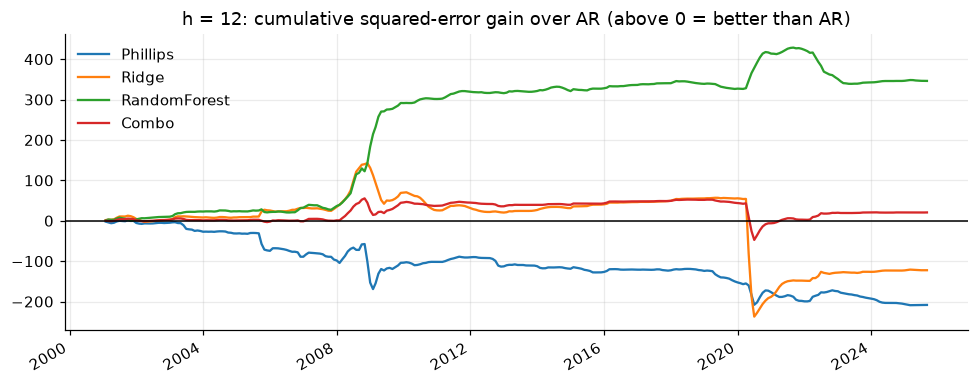

In [6]:
df = FC[12]
fig, ax = plt.subplots(figsize=(9, 3.6))
for m in ["Phillips", "Ridge", "RandomForest", "Combo"]:
    ((df["AR"] - df["actual"]) ** 2 - (df[m] - df["actual"]) ** 2).cumsum().plot(ax=ax, label=m)
ax.axhline(0, color="k", lw=1); ax.legend(frameon=False)
ax.set_title("h = 12: cumulative squared-error gain over AR (above 0 = better than AR)"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig("figures/01_cum_gain_h12.png"); plt.show()

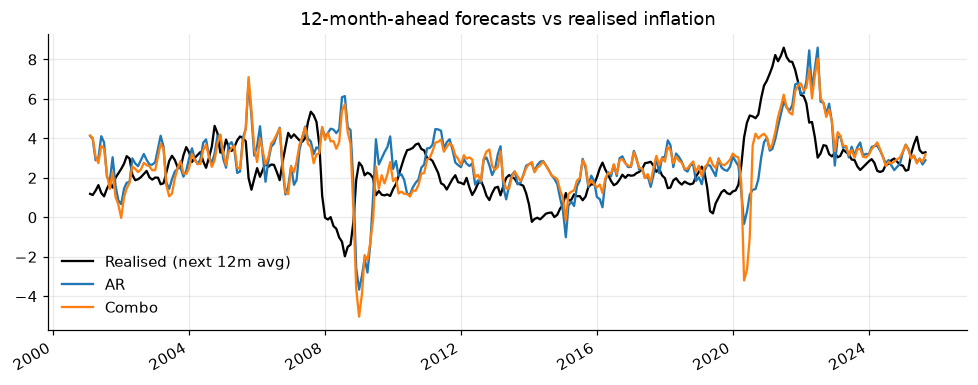

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.6))
df["actual"].plot(ax=ax, color="k", lw=1.5, label="Realised (next 12m avg)")
df["AR"].plot(ax=ax, label="AR"); df["Combo"].plot(ax=ax, label="Combo"); ax.legend(frameon=False)
ax.set_title("12-month-ahead forecasts vs realised inflation"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig("figures/01_forecasts_h12.png"); plt.show()

## 4. Where the random-forest gain comes from
The cumulative-gain figure shows a jump in 2008-2009. The table gives, for 2001-2019, the RMSE ratio of the random forest to the AR and to the 12-month average (RW12), with and without the forecasts made in 2008-2009, and the share of the squared-error gain over the AR that comes from those two years. The sub-samples are not tested.

In [8]:
rows = {}
for h in (3, 6, 12):
    d = FC[h].loc["2001":"2019-12-31"]; crisis = (d.index >= "2008-01-01") & (d.index <= "2009-12-31")
    ratio = lambda z, m, b: np.sqrt(((z[m] - z["actual"]) ** 2).mean() / ((z[b] - z["actual"]) ** 2).mean())
    gain = (d["AR"] - d["actual"]) ** 2 - (d["RandomForest"] - d["actual"]) ** 2
    rows[f"h={h}"] = {"RF / AR": ratio(d, "RandomForest", "AR"), "RF / AR, without 2008-2009": ratio(d[~crisis], "RandomForest", "AR"),
                      "RF / RW12": ratio(d, "RandomForest", "RW12"), "RF / RW12, without 2008-2009": ratio(d[~crisis], "RandomForest", "RW12"),
                      "share of the gain over AR made in 2008-2009": gain[crisis].sum() / gain.sum()}
rob = pd.DataFrame(rows).T.round(2); rob.to_csv("data/out_01_robustness.csv"); rob

,RF / AR,"RF / AR, without 2008-2009",RF / RW12,"RF / RW12, without 2008-2009",share of the gain over AR made in 2008-2009
h=3,0.91,0.93,0.93,1.00,0.62
h=6,0.83,0.94,0.89,1.00,0.85
h=12,0.81,0.92,0.93,1.04,0.78


## 5. How to read this
- Compare the pre-COVID and post-2020 blocks: gains that exist in only one regime are fragile.
- Read the random-forest result with the table above: most of its gain comes from one episode, and outside it the forest does not beat a 12-month average of past inflation.
- A ratio below 1 without stars is not evidence of better forecasting, only of noise in a test sample of a few hundred overlapping observations.
- Conclusions are in the project README.

**Extensions.** Real-time vintages (ALFRED / FRED-MD), survey expectations as predictors, density forecasts scored with the CRPS, a Bayesian VAR benchmark.